# Imports

In [1]:
# Usual stuff
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Path
from pathlib import Path

# HDF5
import h5py

# RegEx
import re

In [2]:
def load_group(name, h5f):
    result = {}
    for k, v in h5f.get(name, {}).items():

        # Extract scalar or array
        val = v[()].item() if np.ndim(v[()]) == 0 else v[()]

        # Decode byte strings automatically
        if isinstance(val, bytes):
            val = val.decode('utf-8')

        # Save the result
        result[k] = val

    return result

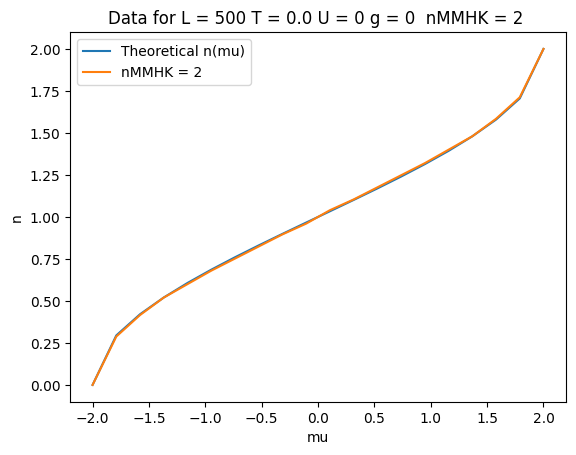

C:\Users\guilh\AppData\Local\Temp\ipykernel_32\1559733985.py:39: RuntimeWarning: invalid value encountered in arccos
  nn = (2 / np.pi) * np.arccos(-0.5 * x_data)


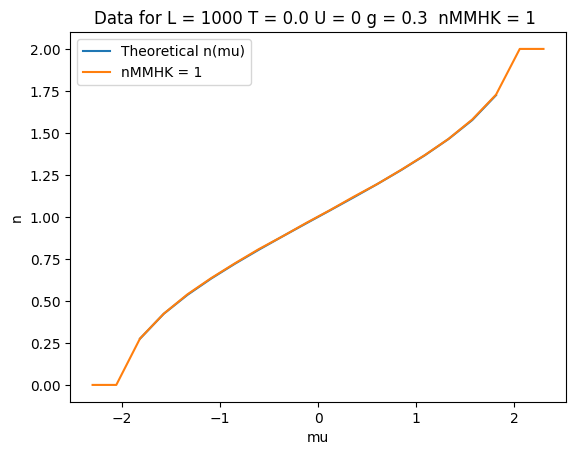

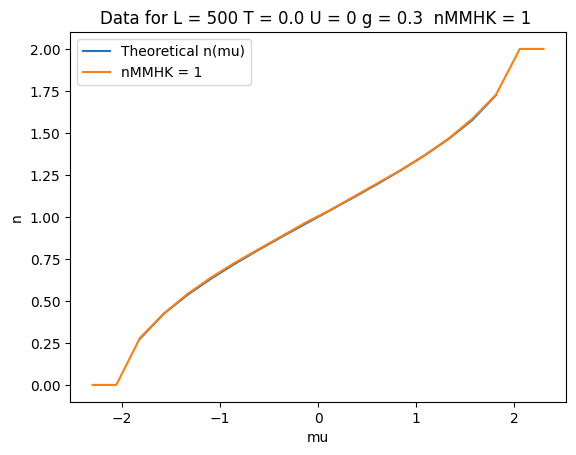

In [3]:
# Choose what to plot
out1 = "n"

# Get the directory where the script is located
current_dir = Path.cwd()

# Get the output directory
current_out = current_dir / "outputs"

# Iterate through all items in the folder
for filepath in current_out.iterdir():
    if filepath.is_file() and str(filepath.suffix) == ".h5":

        # Open the HDF5 file in read mode
        with h5py.File(filepath, "r") as file:
            
            # Read parameters group into a Python dictionary
            params = load_group("params", file)
            sweep1 = load_group("sweep1", file)
            output = load_group("output", file)
            
            # Read root-level sweep data
            x_data = file["ss_data"][()]
            sweep_param = sweep1["param"]
            
            # Extract the correct y_data from the output group
            if out1 in output:
                y_data = output[out1]
            else:
                print(f"Warning: '{out1}' not found in {filepath.name} (skipping).")
                continue
            
            # Title for the plot
            title_str = "Data for " + " ".join(
                f"{key} = {value}" if key not in (sweep1["param"], "mu", "nTarget") else "" for key, value in params.items()
            )

            # Compare to the theoretical n(mu) curve
            nn = (2 / np.pi) * np.arccos(-0.5 * x_data)
            plt.plot(x_data, nn, label=f"Theoretical n(mu)")

            # Make the plot
            plt.plot(x_data, y_data, label=f"nMMHK = {params['nMMHK']}")
            plt.title(title_str)
            plt.xlabel(sweep1["param"])
            plt.ylabel(out1)
            plt.legend()
            plt.show()